# SICKLE EDA

SICKLE (Cauvery Delta, Tamil Nadu) is the **phenology** benchmark: paddy plots with
externally-annotated **sowing / transplanting / harvesting** dates (day-of-season) plus yield,
over Sentinel-1 / Sentinel-2 / Landsat-8 time series. We use it for the `pheno-proxy` regression
task. This notebook explores the annotations, the raw per-plot chips, and the repo `Benchmark`
object that `load_sickle` produces.

> Run with a kernel that has the repo deps (numpy, pandas, matplotlib, rasterio).

## 0. Setup

In [2]:
import sys, importlib.util, glob
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import rasterio

REPO = Path.cwd()
while not (REPO / 'src').exists():
    REPO = REPO.parent

def _load(name, rel):
    spec = importlib.util.spec_from_file_location(name, REPO / rel)
    m = importlib.util.module_from_spec(spec); sys.modules[name] = m; spec.loader.exec_module(m)
    return m

gi = _load('gi_sickle', 'src/dataio/get_input.py')
SICKLE = REPO / 'data' / 'input' / 'sickle'
print('SICKLE dir:', SICKLE, '| exists:', SICKLE.exists())

SICKLE dir: /Users/akshithchowdary/Developer/Projects/org/abe/robustness/data/input/sickle | exists: True


## 1. Tabular annotations
One row per season-sample. Phenology targets are `SOWING_DAY` / `TRANSPLANTING_DAY` /
`HARVESTING_DAY` (day-of-season; 0 = not applicable, e.g. direct-sown plots have no transplant).

In [3]:
df = pd.read_csv(SICKLE / 'sickle_dataset_tabular.csv')
print('rows:', len(df), '| paddy (PADDY_BIN==1):', int((df.PADDY_BIN == 1).sum()))
print('SPLIT:', df.SPLIT.value_counts().to_dict())
df[['UNIQUE_ID','PLOT_ID','RIVER_PART','STANDARD_SEASON','CROP','PADDY_BIN',
    'SOWING_DAY','TRANSPLANTING_DAY','HARVESTING_DAY','YIELD']].head()

rows: 2370 | paddy (PADDY_BIN==1): 907
SPLIT: {'train': 1937, 'val': 227, 'test': 206}


,UNIQUE_ID,PLOT_ID,RIVER_PART,STANDARD_SEASON,CROP,PADDY_BIN,SOWING_DAY,TRANSPLANTING_DAY,HARVESTING_DAY,YIELD
0,0,1.0,Upper Cauvery,jun-oct,Coconut,2.0,0.0,0.0,0.0,0.0
1,1,1.0,Upper Cauvery,aug-jan,Coconut,2.0,0.0,0.0,0.0,0.0
2,2,1.0,Upper Cauvery,sep-feb,Coconut,2.0,0.0,0.0,0.0,0.0
3,3,1.0,Upper Cauvery,dec-may,Coconut,2.0,0.0,0.0,0.0,0.0
4,4,1.0,Upper Cauvery,may-sep,Coconut,2.0,0.0,0.0,0.0,0.0


## 2. Target / group distributions (paddy)

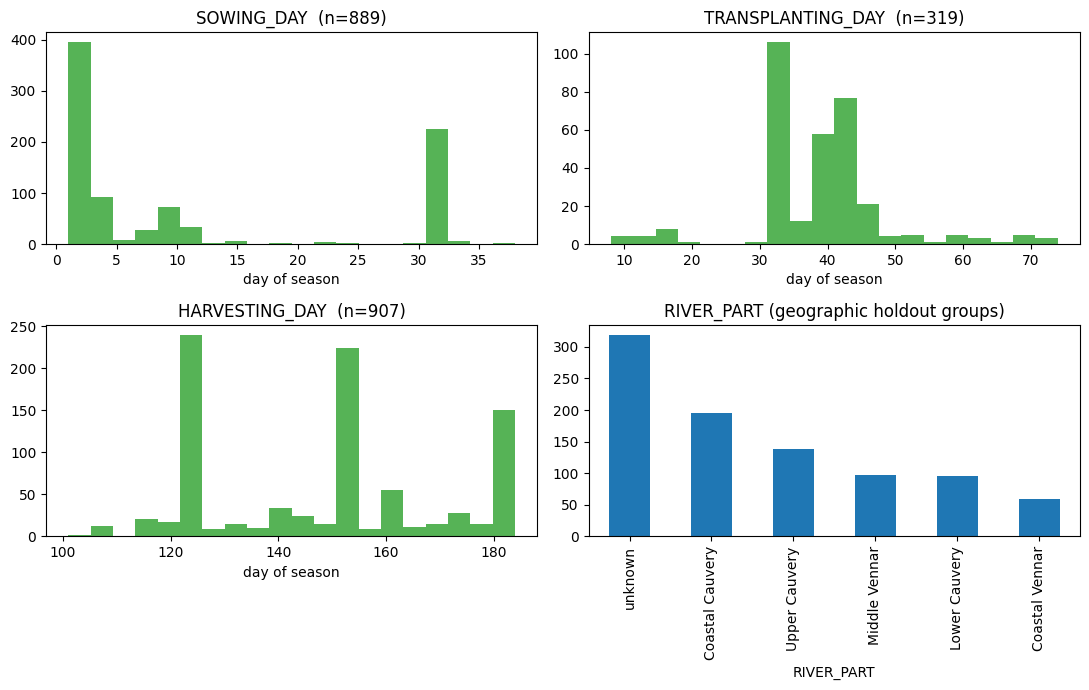

In [4]:
paddy = df[df.PADDY_BIN == 1]
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
for a, col in zip(ax.ravel()[:3], ['SOWING_DAY', 'TRANSPLANTING_DAY', 'HARVESTING_DAY']):
    v = paddy[col][paddy[col] > 0]
    a.hist(v, bins=20, color='tab:green', alpha=0.8)
    a.set_title(f'{col}  (n={len(v)})'); a.set_xlabel('day of season')
paddy.RIVER_PART.fillna('unknown').value_counts().plot.bar(ax=ax[1, 1], color='tab:blue')
ax[1, 1].set_title('RIVER_PART (geographic holdout groups)')
plt.tight_layout(); plt.show()

## 3. One raw sample
Per UID: `images/{S2,S1}/npy/<uid>/*.npz` (one file per acquisition; bands are keys, at their
**native** S2 resolution so 10 m and 20 m bands differ in shape) and `masks/10m/<uid>.tif`
with channels `[plot, crop, sowing, transplanting, harvesting, yield]`.

uid 114 (plot 8): 21 S2 acq, 14 S1 acq
S2 band native shapes: {'B2': (33, 33), 'B4': (33, 33), 'B8': (33, 33), 'B5': (17, 17), 'B11': (17, 17)}
S1 keys: ['VH', 'VV', 'angle']
mask channels [plot,crop,sow,transp,harv,yield]: (6, 33, 33)


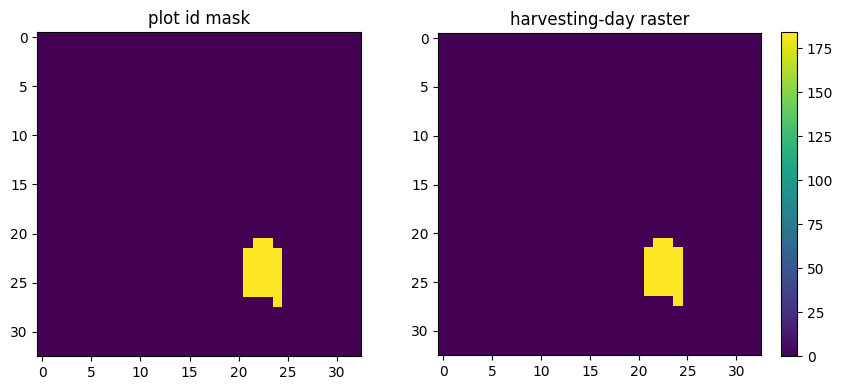

In [5]:
uid = int(paddy[paddy.HARVESTING_DAY > 0].iloc[0].UNIQUE_ID)
plot_id = int(paddy[paddy.UNIQUE_ID == uid].iloc[0].PLOT_ID)
s2_files = sorted(glob.glob(str(SICKLE / 'images/S2/npy' / str(uid) / '*.npz')))
s1_files = sorted(glob.glob(str(SICKLE / 'images/S1/npy' / str(uid) / '*.npz')))
d2 = np.load(s2_files[0]); d1 = np.load(s1_files[0])
print(f'uid {uid} (plot {plot_id}): {len(s2_files)} S2 acq, {len(s1_files)} S1 acq')
print('S2 band native shapes:', {b: d2[b].shape for b in ['B2','B4','B8','B5','B11'] if b in d2})
print('S1 keys:', list(d1.keys()))
with rasterio.open(SICKLE / 'masks/10m' / f'{uid}.tif') as r:
    mask = r.read()
print('mask channels [plot,crop,sow,transp,harv,yield]:', mask.shape)
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(mask[0]); ax[0].set_title('plot id mask')
im = ax[1].imshow(mask[4]); ax[1].set_title('harvesting-day raster'); fig.colorbar(im, ax=ax[1])
plt.tight_layout(); plt.show()

## 4. Repo `Benchmark` via `load_sickle`
`load_sickle` aggregates each plot's pixels (mask `== PLOT_ID`, resized per band), nearest-resamples
the S2/S1 series onto a fixed `timesteps` grid spanning the season, computes NDVI, and puts the chosen
phenology day into `labels`. Groups are river parts.

In [6]:
bench = gi.get_input('sickle', target='harvesting', timesteps=12, max_samples=200, shuffle=True, seed=0)
print('task:', bench.task, '| N:', bench.n_samples, '| T:', bench.timesteps)
print('s2', bench.s2.shape, '| s1', bench.s1.shape, '| bands', bench.s2_bands)
print('harvesting-day: mean %.1f  std %.1f  range [%d, %d]' % (
    bench.labels.mean(), bench.labels.std(), bench.labels.min(), bench.labels.max()))
import collections; print('groups:', dict(collections.Counter(bench.groups)))

FileNotFoundError: SICKLE tabular CSV not found: data/input/sickle/sickle_dataset_tabular.csv

## 5. Phenology signal: NDVI trajectory vs harvest timing
If the imagery carries the harvest signal, plots that harvest later should keep green (high NDVI)
longer. We average the NDVI trajectory for the earliest- vs latest-harvesting thirds.

In [ ]:
ndvi = bench.s2[:, :, bench.s2_bands.index('NDVI')]
order = np.argsort(bench.labels)
k = max(1, len(order) // 3)
early = ndvi[order[:k]].mean(0)
late = ndvi[order[-k:]].mean(0)
plt.figure(figsize=(7, 4))
plt.plot(early, '-o', label='earliest-harvest third')
plt.plot(late, '-o', label='latest-harvest third')
plt.xlabel('resampled timestep'); plt.ylabel('mean NDVI'); plt.legend()
plt.title('NDVI trajectory by harvest timing'); plt.show()

## 6. What the `pheno-proxy` task evaluates
`src/evals/tasks/pheno_proxy.py`: regression on the harvesting day, with **strict geographic
holdout** by river part (train on the rest, test on one held-out river part at a time). Below are
the per-group sizes that drive that split.

In [ ]:
g = pd.Series(bench.groups)
sizes = g.value_counts()
print('river-part group sizes (sampled benchmark):')
print(sizes.to_string())
print('\nHeld out one at a time -> tiny test sets; treat absolute metrics as indicative,')
print('and read Pearson/Spearman (rank) alongside RMSE/MAE.')

## 7. Takeaways
- SICKLE gives **externally-labeled** phenology dates -- a real target, unlike a derived NDVI-peak probe.
- It is small and single-region (Cauvery Delta paddy); the tifs aren't geo-referenced, so `latlon` is a
  fixed centroid (TESSERA, which keys off location, is therefore degenerate here -- use Presto/OlmoEarth).
- Targets are configurable: `target='sowing' | 'transplanting' | 'harvesting'` (harvesting is best-populated).
- Evaluation is regression under strict river-part holdout; rank correlation is the most stable signal.